----
Name: Jubayer Iqbal

ID: 24101512

---

Name: Muhammad Saif Altaf

ID: 24101410

---
Course: CSE422 Lab

Section: 16

Faculty: [RRH], [MHDE]

# **IMPORTINGS**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

# **Connect to Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Load Dataset**

In [ ]:
# Load the dataset
dataset = pd.read_csv("/content/drive/MyDrive/2026/Summer-26/CSE422/Tree_Sterility_Dataset.csv")

# **Overview**

In [ ]:
print(f"Total Features: {dataset.shape[1]}")
print(f"Total Data Points: {dataset.shape[0]}")

Total Features: 24
Total Data Points: 2783


In [ ]:
print(dataset.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2783 entries, 0 to 2782
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   No           2783 non-null   int64  
 1   Plot         2783 non-null   int64  
 2   Subplot      2783 non-null   object 
 3   Species      2783 non-null   object 
 4   Light_ISF    2783 non-null   float64
 5   Light_Cat    2783 non-null   object 
 6   Core         2783 non-null   int64  
 7   Soil         2783 non-null   object 
 8   Adult        2783 non-null   object 
 9   Sterile      2783 non-null   object 
 10  Conspecific  2783 non-null   object 
 11  Myco         2783 non-null   object 
 12  SoilMyco     2783 non-null   object 
 13  PlantDate    2783 non-null   object 
 14  AMF          2783 non-null   float64
 15  EMF          1283 non-null   float64
 16  Phenolics    2783 non-null   float64
 17  Lignin       2783 non-null   float64
 18  NSC          2783 non-null   float64
 19  Census

In [ ]:
dataset.head(5)

,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,Conspecific,Myco,SoilMyco,PlantDate,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
0,126,1,C,Acer saccharum,0.106,Med,2017,Prunus serotina,I,Non-Sterile,Heterospecific,AMF,AMF,6/11/18,22.00,NaN,-0.56,13.86,12.15,4,14.0,1.0,NaN,NaN
1,11,1,C,Quercus alba,0.106,Med,2017,Quercus rubra,970,Non-Sterile,Heterospecific,EMF,EMF,5/25/18,15.82,31.07,5.19,20.52,19.29,33,115.5,0.0,NaN,X
2,12,1,C,Quercus rubra,0.106,Med,2017,Prunus serotina,J,Non-Sterile,Heterospecific,EMF,AMF,5/31/18,24.45,28.19,3.36,24.74,15.01,18,63.0,1.0,NaN,NaN
3,2823,7,D,Acer saccharum,0.080,Med,2016,Prunus serotina,J,Non-Sterile,Heterospecific,AMF,AMF,6/11/18,22.23,NaN,-0.71,14.29,12.36,4,14.0,1.0,NaN,NaN
4,5679,14,A,Acer saccharum,0.060,Low,2017,Prunus serotina,689,Non-Sterile,Heterospecific,AMF,AMF,6/11/18,21.15,NaN,-0.58,10.85,11.20,4,14.0,1.0,NaN,NaN


In [ ]:
dataset.tail(5)

,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,Conspecific,Myco,SoilMyco,PlantDate,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
2778,7165,17,B,Prunus serotina,0.111,Med,2017,Populus grandidentata,891,Non-Sterile,Heterospecific,AMF,EMF,6/7/18,40.89,NaN,0.83,9.15,11.88,16,56.0,1.0,NaN,NaN
2779,7217,17,D,Quercus alba,0.118,Med,2017,Acer rubrum,1468,Non-Sterile,Heterospecific,EMF,AMF,5/25/18,15.47,32.82,4.88,19.01,23.50,16,56.0,1.0,NaN,NaN
2780,7306,17,D,Quercus alba,0.118,Med,2017,Quercus rubra,1454,Non-Sterile,Heterospecific,EMF,EMF,5/25/18,11.96,37.67,5.51,21.13,19.10,16,56.0,1.0,NaN,NaN
2781,7771,18,D,Quercus alba,0.161,High,2017,Sterile,1297,Sterile,Sterilized,EMF,Sterile,5/17/18,16.99,22.51,4.28,19.38,21.36,33,115.5,NaN,NaN,NaN
2782,7401,18,A,Prunus serotina,0.141,High,2016,Populus grandidentata,118,Non-Sterile,Heterospecific,AMF,EMF,6/7/18,60.46,NaN,1.00,9.04,11.82,16,56.0,1.0,NaN,NaN


In [ ]:
dataset.duplicated().sum() # No Duplicate rows

np.int64(0)

**Target Class Distribution**

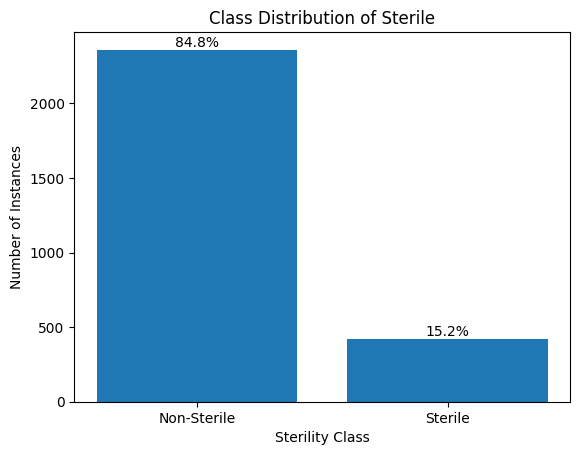

In [ ]:
class_counts = dataset['Sterile'].value_counts()

plt.bar(class_counts.index, class_counts.values)

plt.xlabel('Sterility Class')
plt.ylabel('Number of Instances')
plt.title('Class Distribution of Sterile')

# Add percentage labels
total = class_counts.sum()

for i, value in enumerate(class_counts.values):
    percentage = (value / total) * 100
    plt.text(
        i,
        value,
        f'{percentage:.1f}%',
        ha='center',
        va='bottom'
    )
plt.show()

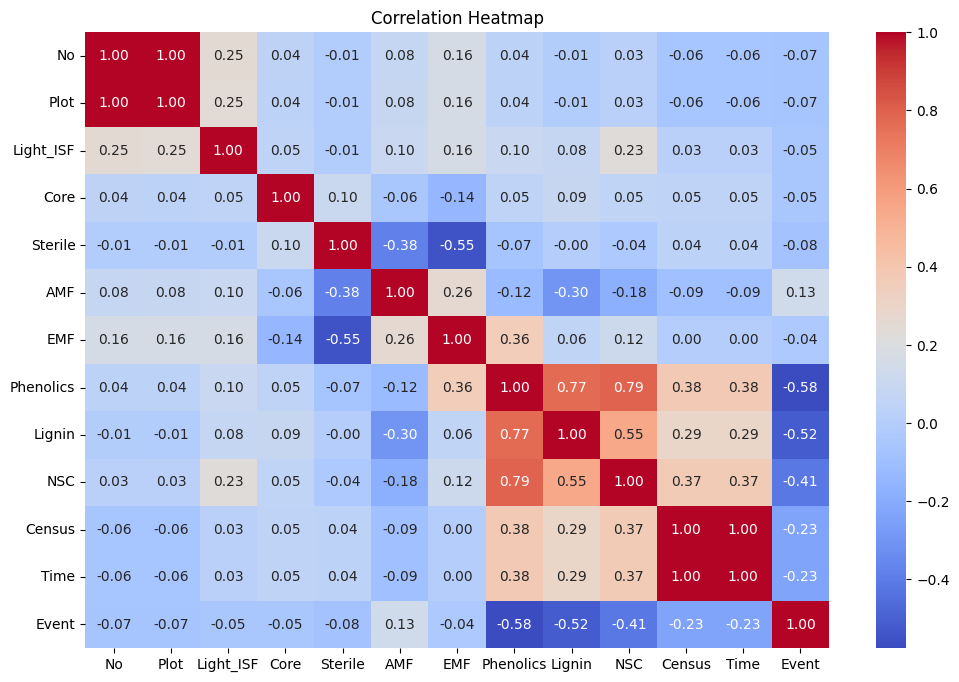

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

dataset_temp = dataset.copy()

dataset_temp["Sterile"] = dataset_temp["Sterile"].map({
    "Non-Sterile": 0,
    "Sterile": 1
})

correlation = dataset_temp.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.show()

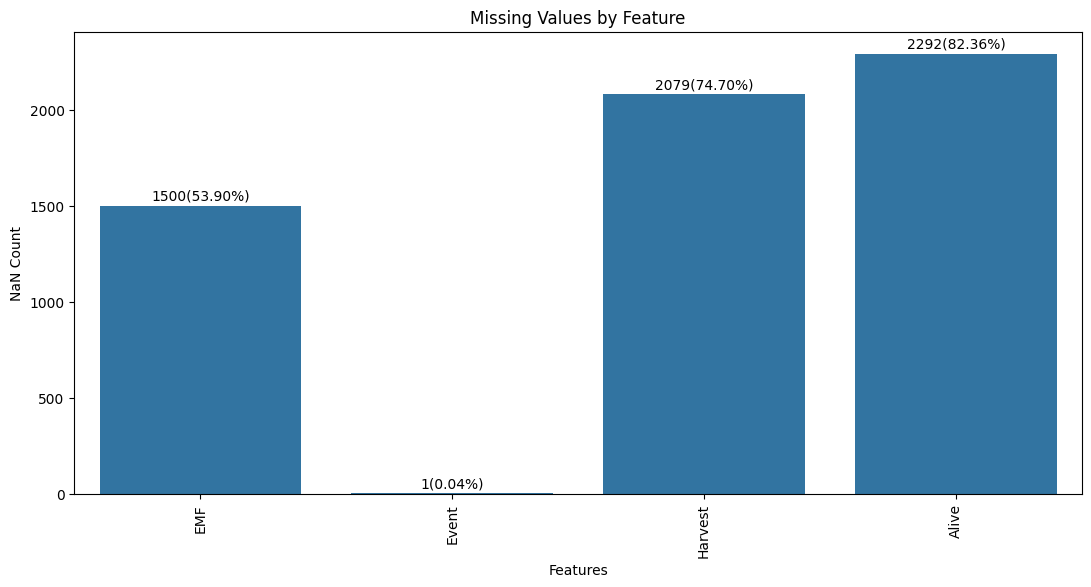

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

nan_counts = dataset.isna().sum()
nan_counts = nan_counts[nan_counts > 0]

plt.figure(figsize=(13, 6))

ax = sns.barplot(
    x=nan_counts.index,
    y=nan_counts.values
)

for i, value in enumerate(nan_counts.values):
  ax.text(i, value + 30, f"{value}({value/dataset.shape[0]*100:.02F}%)", ha="center")

plt.xlabel("Features")
plt.ylabel("NaN Count")
plt.title("Missing Values by Feature")
plt.xticks(rotation=90)

plt.show()

**Investigating Time and Census Relationship**

In [ ]:
dataset[["Time", "Census"]].head(5)

,Time,Census
0,14.0,4
1,115.5,33
2,63.0,18
3,14.0,4
4,14.0,4


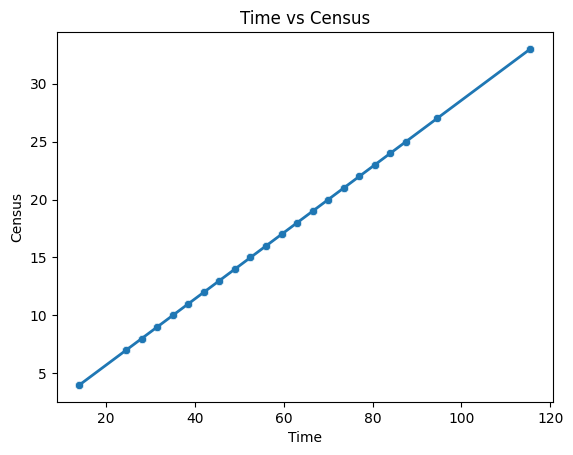

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.scatterplot(data=dataset, x="Time", y="Census")

# Fit a straight line
m, b = np.polyfit(dataset["Time"], dataset["Census"], 1)

# Generate line values
x = np.linspace(dataset["Time"].min(), dataset["Time"].max(), 100)
y = m * x + b

plt.plot(x, y, linewidth=2)

plt.xlabel("Time")
plt.ylabel("Census")
plt.title("Time vs Census")

plt.show()

In [ ]:
print((dataset_temp["Time"] == dataset_temp["Census"] * 3.5).all())

True


In [ ]:
dataset.head(20)

,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,Conspecific,Myco,SoilMyco,PlantDate,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
0,126,1,C,Acer saccharum,0.106,Med,2017,Prunus serotina,I,Non-Sterile,Heterospecific,AMF,AMF,6/11/18,22.00,NaN,-0.56,13.86,12.15,4,14.0,1.0,NaN,NaN
1,11,1,C,Quercus alba,0.106,Med,2017,Quercus rubra,970,Non-Sterile,Heterospecific,EMF,EMF,5/25/18,15.82,31.07,5.19,20.52,19.29,33,115.5,0.0,NaN,X
2,12,1,C,Quercus rubra,0.106,Med,2017,Prunus serotina,J,Non-Sterile,Heterospecific,EMF,AMF,5/31/18,24.45,28.19,3.36,24.74,15.01,18,63.0,1.0,NaN,NaN
3,2823,7,D,Acer saccharum,0.080,Med,2016,Prunus serotina,J,Non-Sterile,Heterospecific,AMF,AMF,6/11/18,22.23,NaN,-0.71,14.29,12.36,4,14.0,1.0,NaN,NaN
4,5679,14,A,Acer saccharum,0.060,Low,2017,Prunus serotina,689,Non-Sterile,Heterospecific,AMF,AMF,6/11/18,21.15,NaN,-0.58,10.85,11.20,4,14.0,1.0,NaN,NaN
5,18,1,C,Prunus serotina,0.106,Med,2016,Acer rubrum,1332,Non-Sterile,Heterospecific,AMF,AMF,6/5/18,35.29,NaN,0.30,10.80,13.79,7,24.5,1.0,NaN,NaN
6,25,1,A,Quercus alba,0.108,Med,2016,Populus grandidentata,891,Non-Sterile,Heterospecific,EMF,EMF,5/25/18,24.00,20.00,5.11,18.82,22.51,7,24.5,0.0,X,NaN
7,40,1,A,Quercus rubra,0.108,Med,2017,Sterile,1595,Sterile,Sterilized,EMF,Sterile,5/23/18,4.00,0.00,3.43,25.22,14.81,7,24.5,0.0,X,NaN
8,26,1,A,Quercus rubra,0.108,Med,2016,Acer saccharum,1323,Non-Sterile,Heterospecific,EMF,AMF,5/29/18,28.74,36.18,3.83,26.65,14.65,33,115.5,0.0,NaN,X
9,41,1,A,Acer saccharum,0.108,Med,2016,Populus grandidentata,394,Non-Sterile,Heterospecific,AMF,EMF,6/4/18,14.16,NaN,-0.05,13.30,12.16,7,24.5,1.0,NaN,NaN


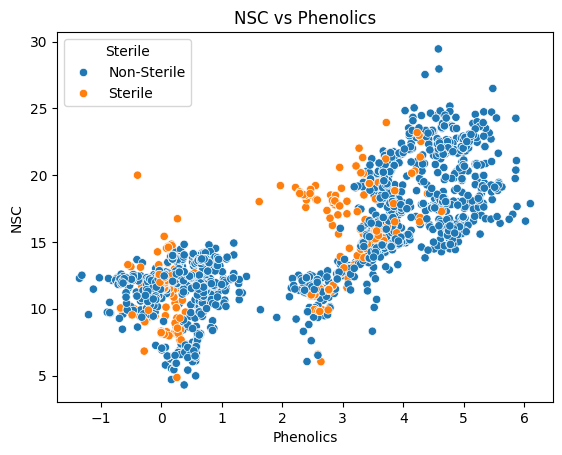

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(data=dataset, x="Phenolics", y="NSC", hue="Sterile")

plt.xlabel("Phenolics")
plt.ylabel("NSC")
plt.title("NSC vs Phenolics")

plt.show()

**Inspecting Outliers**

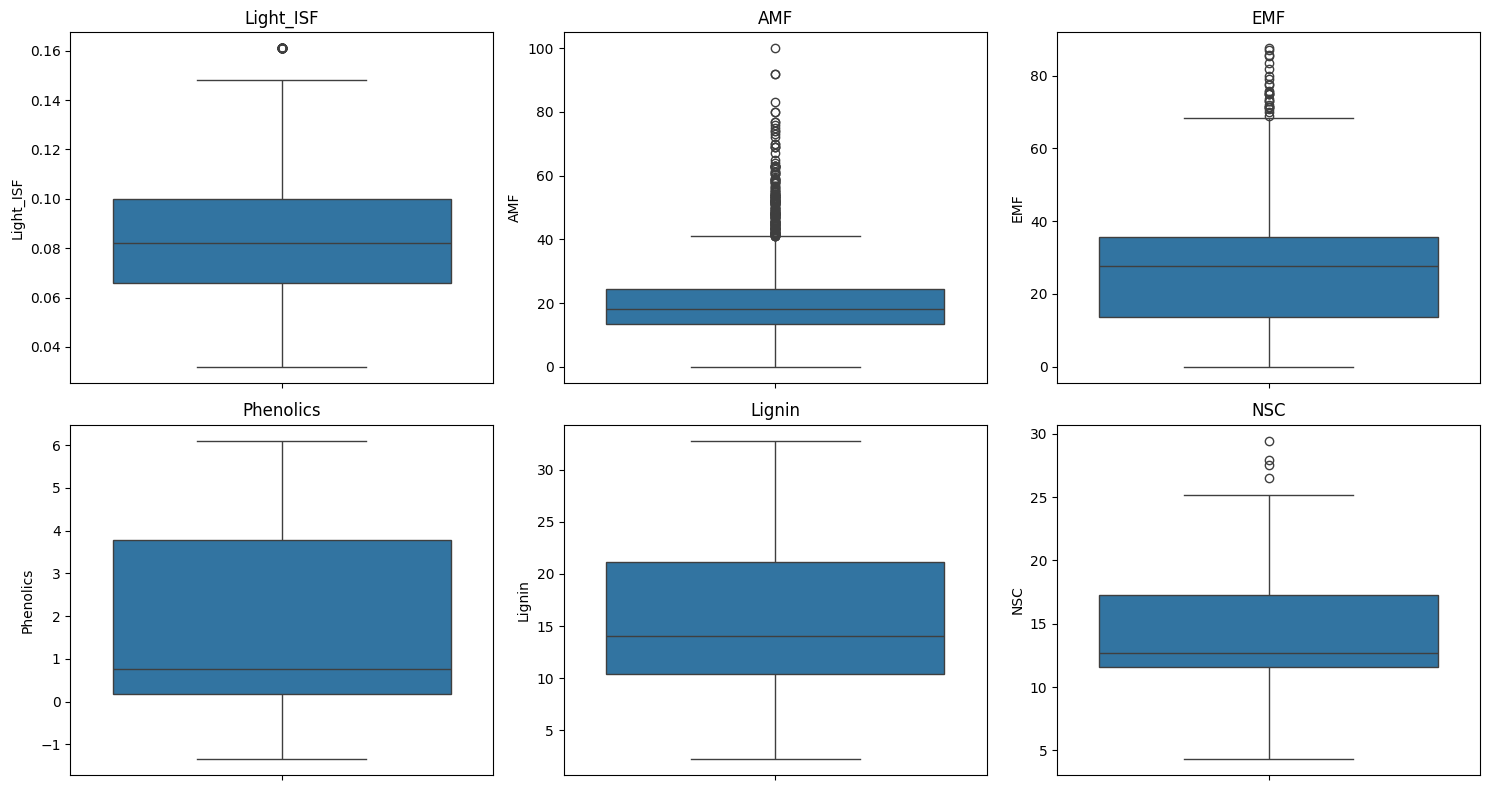

In [ ]:
numerical_cols = [
    "Light_ISF", "AMF", "EMF",
    "Phenolics", "Lignin", "NSC"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, numerical_cols):
    sns.boxplot(data=dataset, y=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
numerical_columns = [
    "Plot", "Light_ISF", "Core",
    "AMF", "EMF", "Phenolics",
    "Lignin", "NSC", "Time", "Event"
]

outlier_counts = {}

for col in numerical_columns:
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = dataset[
        (dataset[col] < lower_bound) |
        (dataset[col] > upper_bound)
    ]

    count = len(outliers)

    if count > 0:
        outlier_counts[col] = count

print(outlier_counts)

{'Light_ISF': 44, 'AMF': 180, 'EMF': 25, 'NSC': 4}


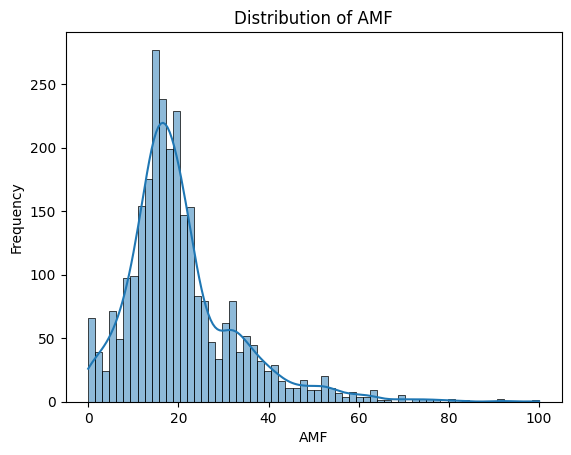

In [ ]:
sns.histplot(data=dataset, x="AMF", kde=True)

plt.title("Distribution of AMF")
plt.xlabel("AMF")
plt.ylabel("Frequency")
plt.show()

In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2783 entries, 0 to 2782
Data columns (total 24 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   No           2783 non-null   int64  
 1   Plot         2783 non-null   int64  
 2   Subplot      2783 non-null   object 
 3   Species      2783 non-null   object 
 4   Light_ISF    2783 non-null   float64
 5   Light_Cat    2783 non-null   object 
 6   Core         2783 non-null   int64  
 7   Soil         2783 non-null   object 
 8   Adult        2783 non-null   object 
 9   Sterile      2783 non-null   object 
 10  Conspecific  2783 non-null   object 
 11  Myco         2783 non-null   object 
 12  SoilMyco     2783 non-null   object 
 13  PlantDate    2783 non-null   object 
 14  AMF          2783 non-null   float64
 15  EMF          1283 non-null   float64
 16  Phenolics    2783 non-null   float64
 17  Lignin       2783 non-null   float64
 18  NSC          2783 non-null   float64
 19  Census

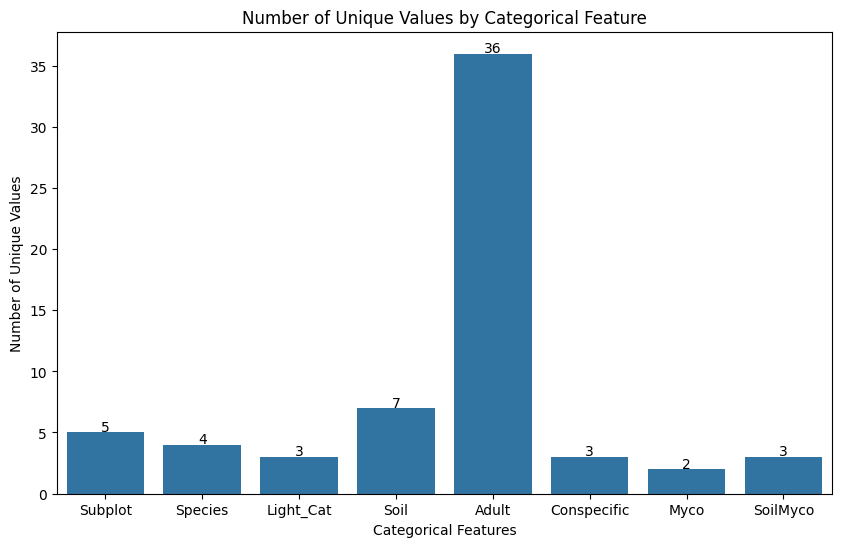

In [ ]:
categorical_variables = ["Subplot", "Species", "Light_Cat", "Soil", "Adult", "Conspecific", "Myco", "SoilMyco", ]

unique_counts = dataset[categorical_variables].nunique()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=unique_counts.index,
    y=unique_counts.values
)

plt.xlabel("Categorical Features")
plt.ylabel("Number of Unique Values")
plt.title("Number of Unique Values by Categorical Feature")

for i, value in enumerate(unique_counts.values):
    ax.text(i, value + 0.1, str(value), ha="center")

plt.show()

**Analyzing Catergorical Features and Sterile Relationship**

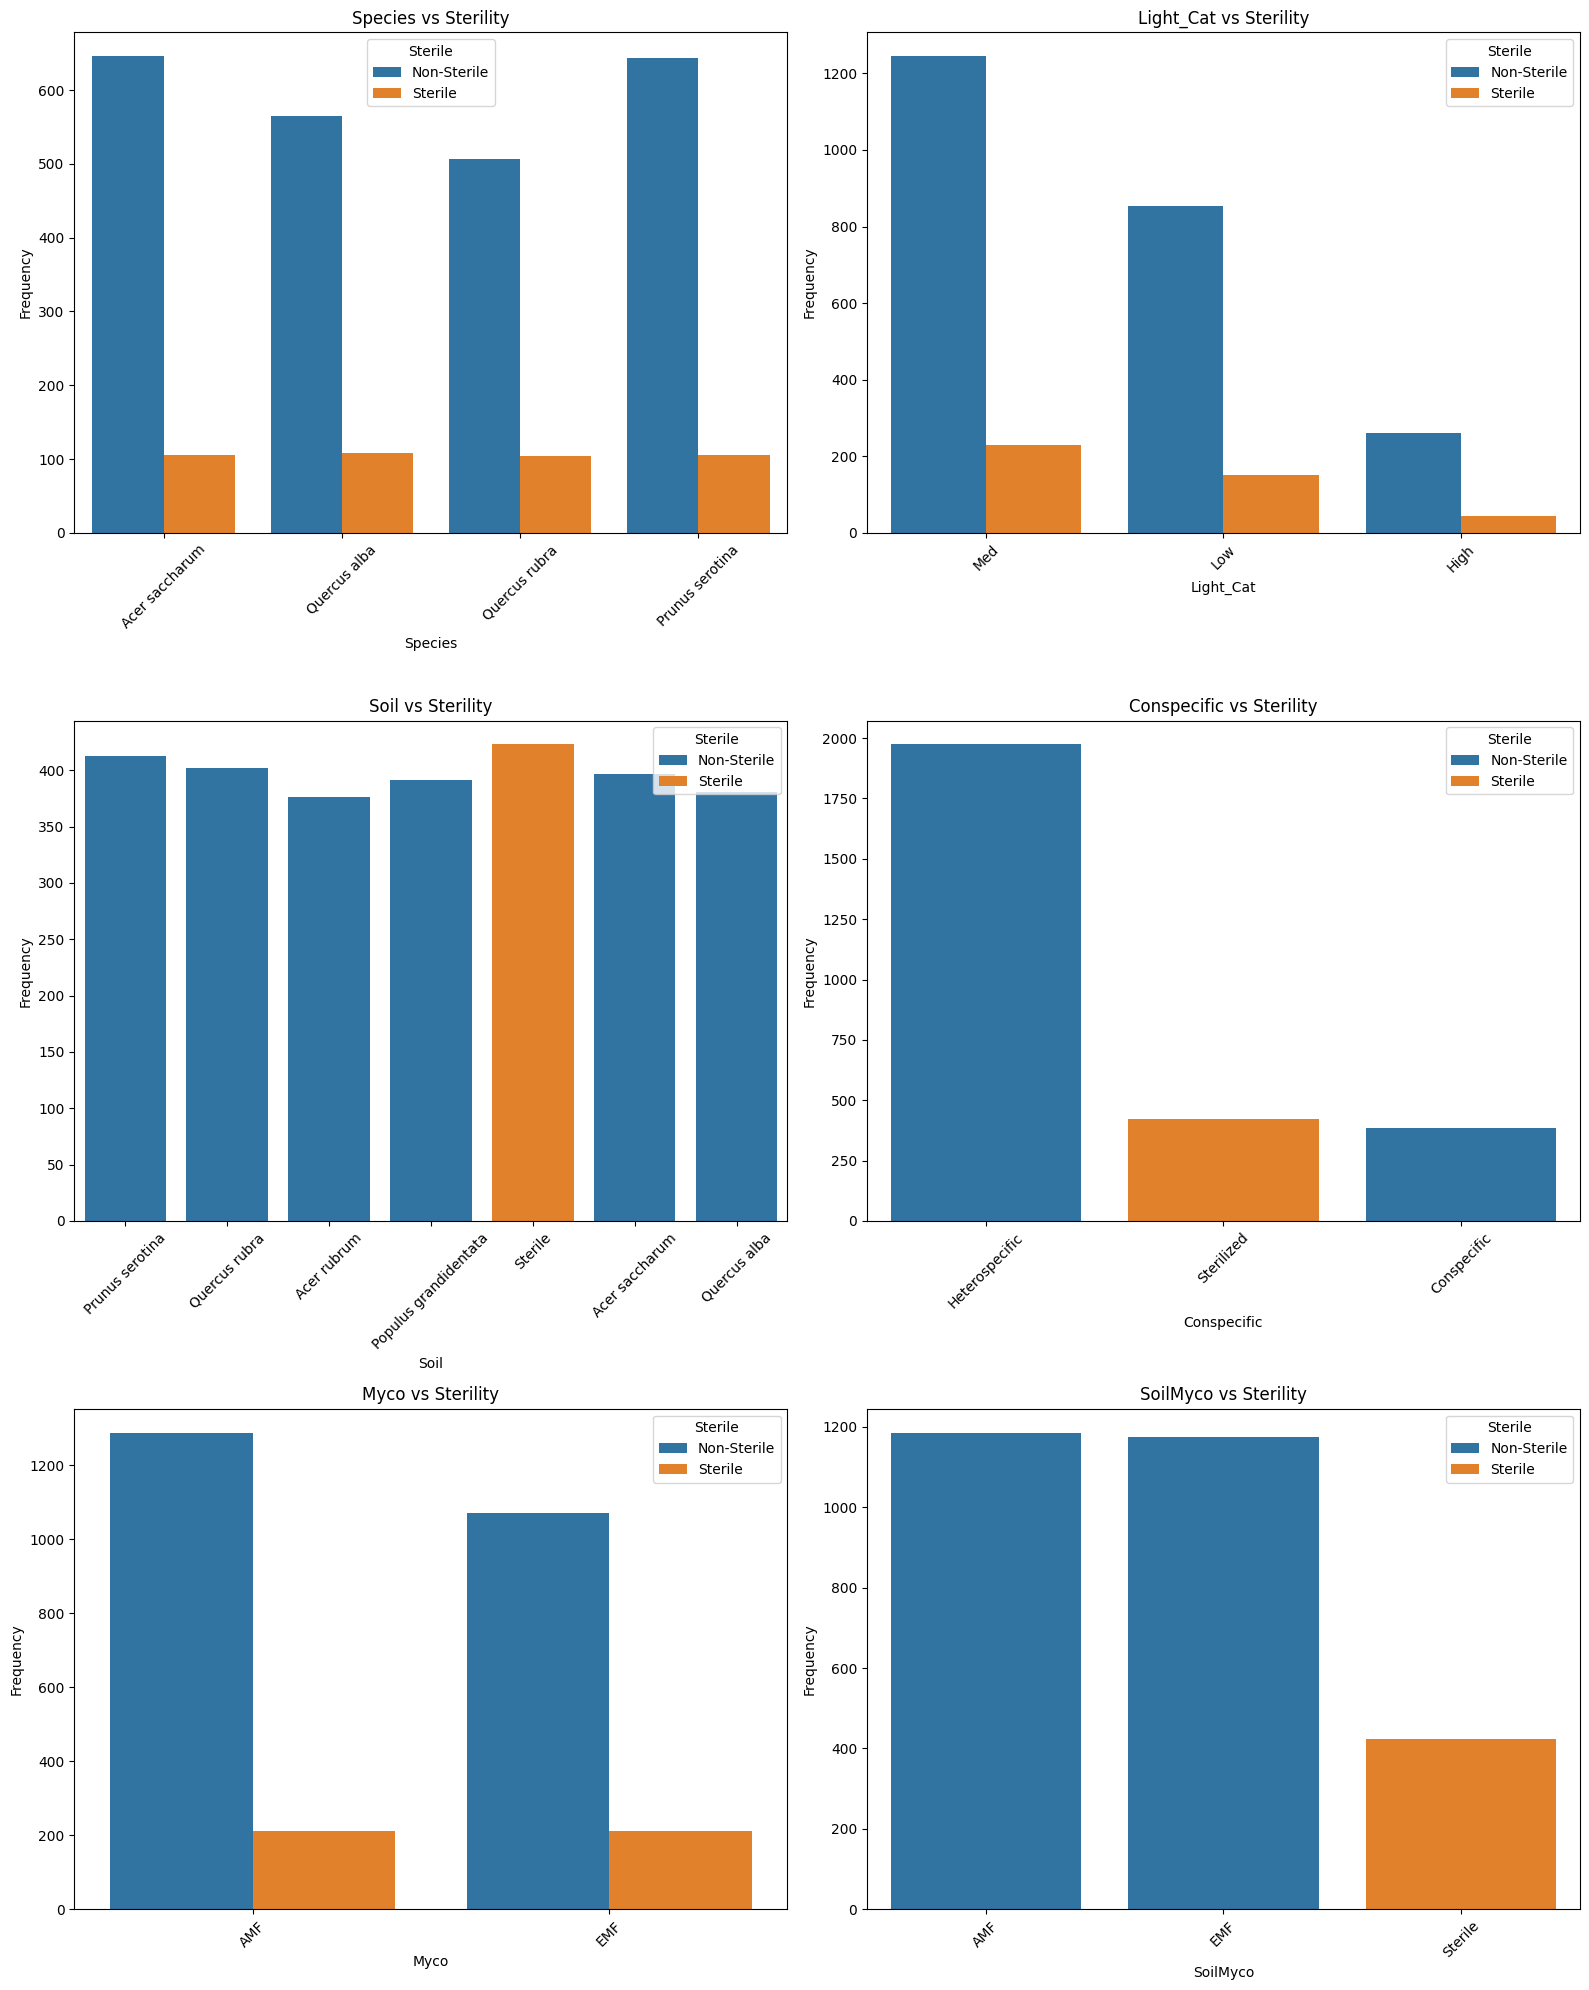

In [ ]:
categorical_variables = ["Species", "Light_Cat", "Soil", "Conspecific", "Myco", "SoilMyco"]

fig, axes = plt.subplots(3, 2, figsize=(16, 20))
axes = axes.flatten()

for ax, col in zip(axes, categorical_variables):
    sns.countplot(
        data=dataset,
        x=col,
        hue="Sterile",
        ax=ax
    )

    ax.set_title(f"{col} vs Sterility")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

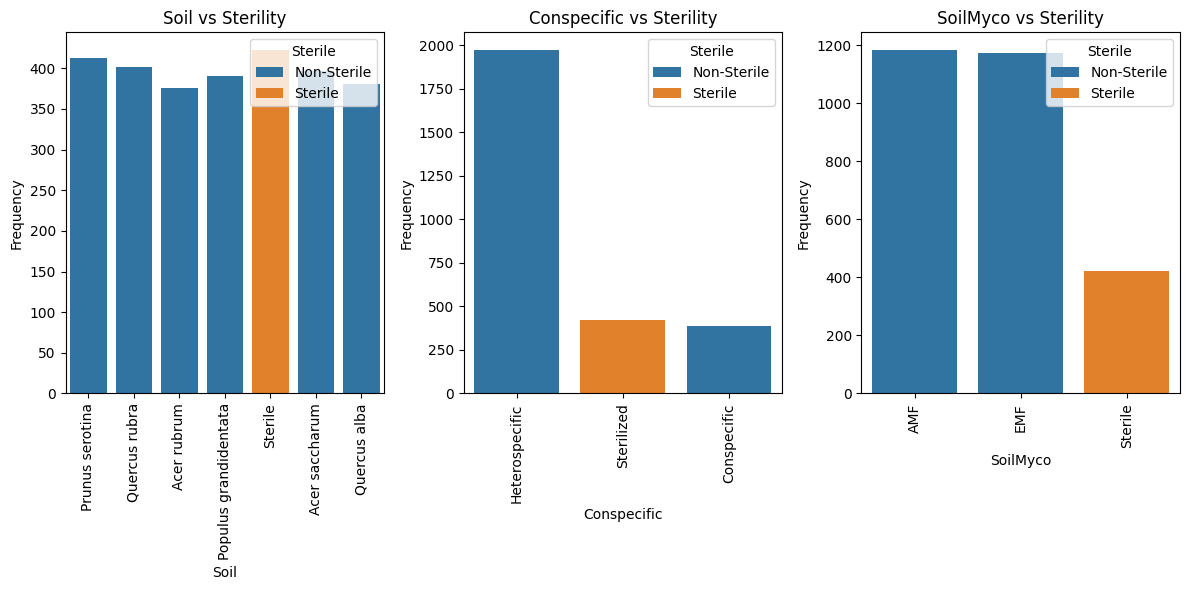

In [ ]:
categorical_variables = ["Soil", "Conspecific", "SoilMyco"]

fig, axes = plt.subplots(1, 3, figsize=(12, 6))
axes = axes.flatten()

for ax, col in zip(axes, categorical_variables):
    sns.countplot(
        data=dataset,
        x=col,
        hue="Sterile",
        ax=ax
    )

    ax.set_title(f"{col} vs Sterility")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
dataset.tail()

,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,Conspecific,Myco,SoilMyco,PlantDate,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
2778,7165,17,B,Prunus serotina,0.111,Med,2017,Populus grandidentata,891,Non-Sterile,Heterospecific,AMF,EMF,6/7/18,40.89,NaN,0.83,9.15,11.88,16,56.0,1.0,NaN,NaN
2779,7217,17,D,Quercus alba,0.118,Med,2017,Acer rubrum,1468,Non-Sterile,Heterospecific,EMF,AMF,5/25/18,15.47,32.82,4.88,19.01,23.50,16,56.0,1.0,NaN,NaN
2780,7306,17,D,Quercus alba,0.118,Med,2017,Quercus rubra,1454,Non-Sterile,Heterospecific,EMF,EMF,5/25/18,11.96,37.67,5.51,21.13,19.10,16,56.0,1.0,NaN,NaN
2781,7771,18,D,Quercus alba,0.161,High,2017,Sterile,1297,Sterile,Sterilized,EMF,Sterile,5/17/18,16.99,22.51,4.28,19.38,21.36,33,115.5,NaN,NaN,NaN
2782,7401,18,A,Prunus serotina,0.141,High,2016,Populus grandidentata,118,Non-Sterile,Heterospecific,AMF,EMF,6/7/18,60.46,NaN,1.00,9.04,11.82,16,56.0,1.0,NaN,NaN


In [ ]:
dataset[["Light_ISF", "Light_Cat"]].head(20)

,Light_ISF,Light_Cat
0,0.106,Med
1,0.106,Med
2,0.106,Med
3,0.080,Med
4,0.060,Low
5,0.106,Med
6,0.108,Med
7,0.108,Med
8,0.108,Med
9,0.108,Med


In [ ]:
dataset.groupby("Light_Cat")["Light_ISF"].describe()

,count,mean,std,min,25%,50%,75%,max
Light_Cat,,,,,,,,
High,304.0,0.137507,0.011996,0.122,0.133,0.138,0.141,0.161
Low,1005.0,0.060985,0.010094,0.032,0.055,0.061,0.068,0.075
Med,1474.0,0.091879,0.011553,0.076,0.082,0.087,0.103,0.118


In [ ]:
dataset.head(5)

,No,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Soil,Adult,Sterile,Conspecific,Myco,SoilMyco,PlantDate,AMF,EMF,Phenolics,Lignin,NSC,Census,Time,Event,Harvest,Alive
0,126,1,C,Acer saccharum,0.106,Med,2017,Prunus serotina,I,Non-Sterile,Heterospecific,AMF,AMF,6/11/18,22.00,NaN,-0.56,13.86,12.15,4,14.0,1.0,NaN,NaN
1,11,1,C,Quercus alba,0.106,Med,2017,Quercus rubra,970,Non-Sterile,Heterospecific,EMF,EMF,5/25/18,15.82,31.07,5.19,20.52,19.29,33,115.5,0.0,NaN,X
2,12,1,C,Quercus rubra,0.106,Med,2017,Prunus serotina,J,Non-Sterile,Heterospecific,EMF,AMF,5/31/18,24.45,28.19,3.36,24.74,15.01,18,63.0,1.0,NaN,NaN
3,2823,7,D,Acer saccharum,0.080,Med,2016,Prunus serotina,J,Non-Sterile,Heterospecific,AMF,AMF,6/11/18,22.23,NaN,-0.71,14.29,12.36,4,14.0,1.0,NaN,NaN
4,5679,14,A,Acer saccharum,0.060,Low,2017,Prunus serotina,689,Non-Sterile,Heterospecific,AMF,AMF,6/11/18,21.15,NaN,-0.58,10.85,11.20,4,14.0,1.0,NaN,NaN


# **Data Cleaning and Preprocessing**

**Feature Drop**

In [ ]:
dataset_cleaned = dataset.drop(columns=["No", "Soil", "PlantDate", "Adult", "SoilMyco", "Census", "Harvest", "Alive", "Conspecific", "EMF"])

**Imputing**

In [ ]:
dataset_cleaned["Event"] = dataset_cleaned["Event"].fillna(dataset_cleaned["Event"].mode()[0])

In [ ]:
dataset_cleaned.head(5)

,Plot,Subplot,Species,Light_ISF,Light_Cat,Core,Sterile,Myco,AMF,Phenolics,Lignin,NSC,Time,Event
0,1,C,Acer saccharum,0.106,Med,2017,Non-Sterile,AMF,22.00,-0.56,13.86,12.15,14.0,1.0
1,1,C,Quercus alba,0.106,Med,2017,Non-Sterile,EMF,15.82,5.19,20.52,19.29,115.5,0.0
2,1,C,Quercus rubra,0.106,Med,2017,Non-Sterile,EMF,24.45,3.36,24.74,15.01,63.0,1.0
3,7,D,Acer saccharum,0.080,Med,2016,Non-Sterile,AMF,22.23,-0.71,14.29,12.36,14.0,1.0
4,14,A,Acer saccharum,0.060,Low,2017,Non-Sterile,AMF,21.15,-0.58,10.85,11.20,14.0,1.0


**Encoding**

In [ ]:
categorical_variables = ["Subplot", "Species", "Sterile", "Myco", "Light_Cat"]
numerical_variables = ["Plot", "Light_ISF", "Core", "AMF", "Phenolics", "Lignin", "NSC", "Time", "Event"]

In [ ]:
for col in categorical_variables:
    print(f"{col}:")
    print(dataset_cleaned[col].unique())
    print()

Subplot:
['C' 'D' 'A' 'B' 'E']

Species:
['Acer saccharum' 'Quercus alba' 'Quercus rubra' 'Prunus serotina']

Sterile:
['Non-Sterile' 'Sterile']

Myco:
['AMF' 'EMF']

Light_Cat:
['Med' 'Low' 'High']



In [ ]:
Nominal = ["Subplot", "Species", "Myco"]
Ordinal = ["Light_Cat"]
Binary = ["Sterile"]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [ ]:
X = dataset_cleaned.drop("Sterile", axis=1)
y = dataset_cleaned["Sterile"].map({
    "Non-Sterile": 0,
    "Sterile": 1
})

In [ ]:
transformers=[
    ("nominal",
      OneHotEncoder(handle_unknown="ignore", sparse_output=False),
      Nominal
    ),
    (
      "ordinal",
      OrdinalEncoder(
          categories=[["Low", "Med", "High"]]
      ),
      Ordinal
    )
  ]

preprocessor = ColumnTransformer(transformers, remainder="passthrough")

In [ ]:
X_encoded = preprocessor.fit_transform(X)

In [ ]:
feature_names = preprocessor.get_feature_names_out()

In [ ]:
X_encoded_df = pd.DataFrame(
    X_encoded,
    columns=feature_names,
    index=X.index
)

X_encoded_df.shape

(2783, 21)

In [ ]:
X_encoded_df

,nominal__Subplot_A,nominal__Subplot_B,nominal__Subplot_C,nominal__Subplot_D,nominal__Subplot_E,nominal__Species_Acer saccharum,nominal__Species_Prunus serotina,nominal__Species_Quercus alba,nominal__Species_Quercus rubra,nominal__Myco_AMF,nominal__Myco_EMF,ordinal__Light_Cat,remainder__Plot,remainder__Light_ISF,remainder__Core,remainder__AMF,remainder__Phenolics,remainder__Lignin,remainder__NSC,remainder__Time,remainder__Event
0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.106,2017.0,22.00,-0.56,13.86,12.15,14.0,1.0
1,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.106,2017.0,15.82,5.19,20.52,19.29,115.5,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.106,2017.0,24.45,3.36,24.74,15.01,63.0,1.0
3,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,7.0,0.080,2016.0,22.23,-0.71,14.29,12.36,14.0,1.0
4,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,14.0,0.060,2017.0,21.15,-0.58,10.85,11.20,14.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2778,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,17.0,0.111,2017.0,40.89,0.83,9.15,11.88,56.0,1.0
2779,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,17.0,0.118,2017.0,15.47,4.88,19.01,23.50,56.0,1.0
2780,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,17.0,0.118,2017.0,11.96,5.51,21.13,19.10,56.0,1.0
2781,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,2.0,18.0,0.161,2017.0,16.99,4.28,19.38,21.36,115.5,1.0


# **Data Splitting**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded_df,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

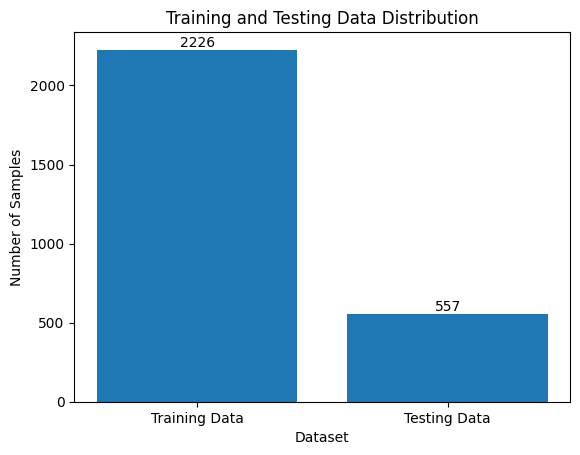

In [ ]:
import matplotlib.pyplot as plt

train_size = len(X_train)
test_size = len(X_test)

plt.bar(
    ["Training Data", "Testing Data"],
    [train_size, test_size]
)

plt.xlabel("Dataset")
plt.ylabel("Number of Samples")
plt.title("Training and Testing Data Distribution")

for i, value in enumerate([train_size, test_size]):
    plt.text(i, value + 20, str(value), ha="center")

plt.show()

In [ ]:
print("Original:")
print(y.value_counts(normalize=True) * 100)

print("\nTraining:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting:")
print(y_test.value_counts(normalize=True) * 100)

Original:
Sterile
0    84.800575
1    15.199425
Name: proportion, dtype: float64

Training:
Sterile
0    84.815813
1    15.184187
Name: proportion, dtype: float64

Testing:
Sterile
0    84.739677
1    15.260323
Name: proportion, dtype: float64


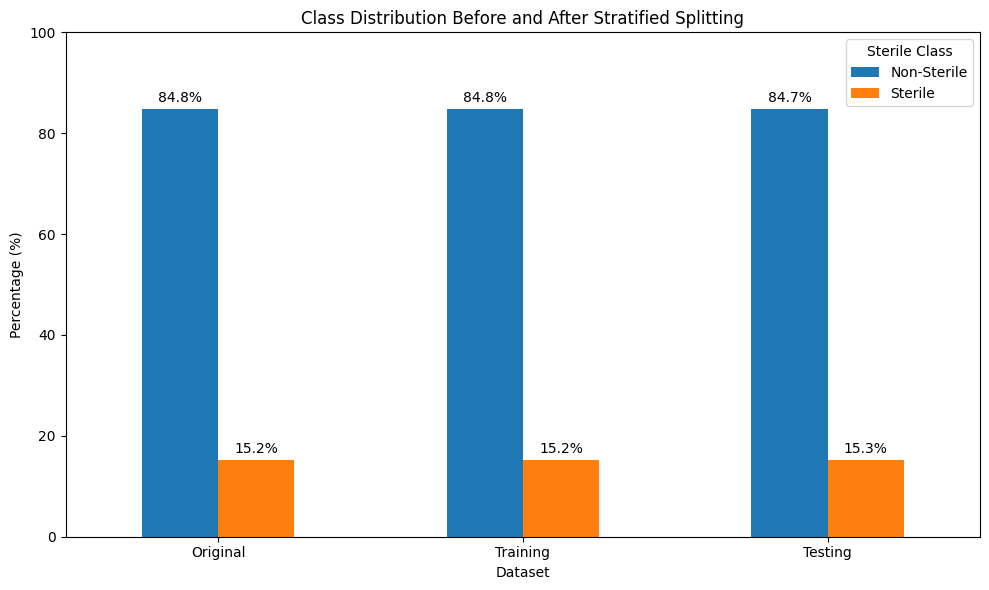

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

distribution = pd.DataFrame({
    "Original": y.value_counts(normalize=True) * 100,
    "Training": y_train.value_counts(normalize=True) * 100,
    "Testing": y_test.value_counts(normalize=True) * 100
}).T

ax = distribution.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Dataset")
plt.ylabel("Percentage (%)")
plt.title("Class Distribution Before and After Stratified Splitting")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(
    title="Sterile Class",
    labels=["Non-Sterile", "Sterile"]
)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

plt.tight_layout()
plt.show()

**Scaling**

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# **Model Training**

**Logistic Regression Model Training**

In [ ]:
from sklearn.linear_model import LogisticRegression

logistic_regression = LogisticRegression(max_iter=1000,
    class_weight="balanced",
    random_state=42
)

logistic_regression.fit(X_train, y_train)


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

**K-Nearest Neighbour Model Training**

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)


KNeighborsClassifier()

**Naive Bayes Model Training**

In [ ]:
from sklearn.naive_bayes import GaussianNB

naive_bayes = GaussianNB()

naive_bayes.fit(X_train, y_train)

GaussianNB()

**Neural Network Model Training**

In [ ]:
from sklearn.neural_network import MLPClassifier

neural_network = MLPClassifier(
    hidden_layer_sizes=(32, 16),
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    alpha=0.001,
)

neural_network.fit(X_train, y_train)

MLPClassifier(alpha=0.001, early_stopping=True, hidden_layer_sizes=(32, 16),
              max_iter=1000, random_state=42)

**K-means Model Training**

In [ ]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

X_scaled = scaler.fit_transform(X_encoded_df)

kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
clusters = kmeans.fit_predict(X_pca)

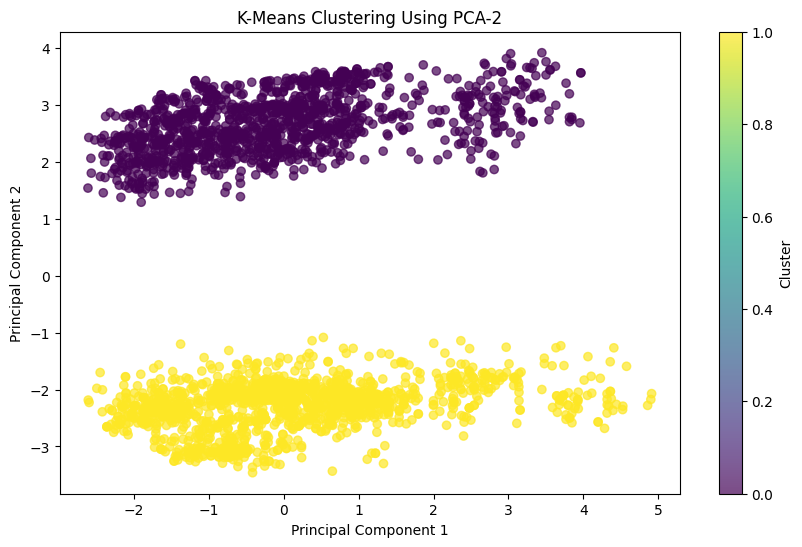

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    X_pca[:, 1],
    X_pca[:, 0],
    c=clusters,
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clustering Using PCA-2")
plt.colorbar(label="Cluster")

plt.show()

# **Model Selection / Comparison Analysis**

In [ ]:
y_pred_lr = logistic_regression.predict(X_test)
y_pred_knn = knn.predict(X_test)
y_pred_nb = naive_bayes.predict(X_test)
y_pred_nn = neural_network.predict(X_test)

models = {
    "Logistic Regression": y_pred_lr,
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nb,
    "Neural Network": y_pred_nn
}

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

comparison = []

for name, predictions in models.items():
    comparison.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1_Score": f1_score(y_test, predictions)
    })

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy,Precision,Recall,F1_Score
0,Logistic Regression,0.910233,0.640000,0.941176,0.761905
1,KNN,0.859964,0.620690,0.211765,0.315789
2,Naive Bayes,0.868941,0.676471,0.270588,0.386555
3,Neural Network,0.915619,0.839286,0.552941,0.666667


**Accuracy Comparison**

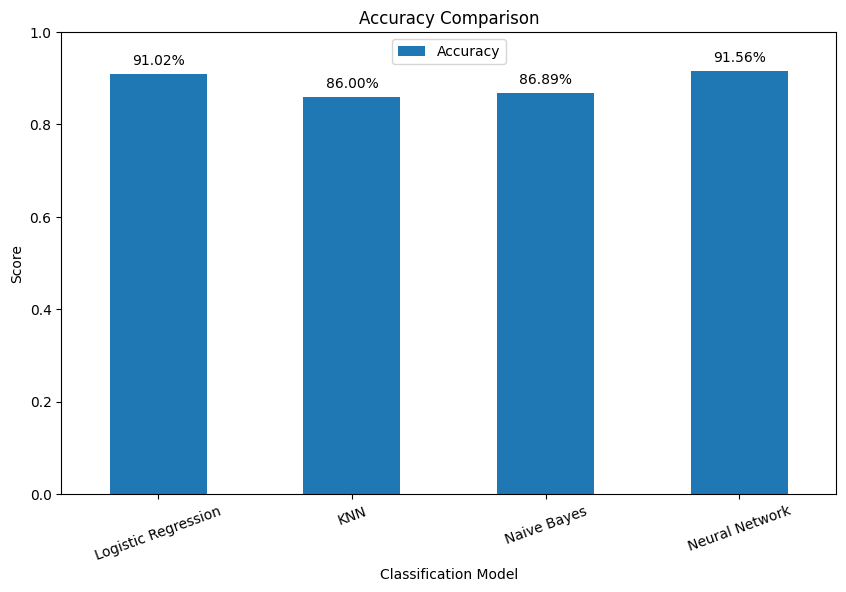

In [ ]:
comparison_df.plot(
    x="Model",
    y=["Accuracy"],
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Classification Model")
plt.ylabel("Score")
plt.title("Accuracy Comparison")
plt.ylim(0, 1)

# Add percentage labels
for i, value in enumerate(comparison_df["Accuracy"]):
    plt.text(
        i,
        value + 0.02,
        f"{value:.2%}",
        ha="center"
    )

plt.xticks(rotation=20)
plt.legend()
plt.show()

**Precision and Recall Comparison**

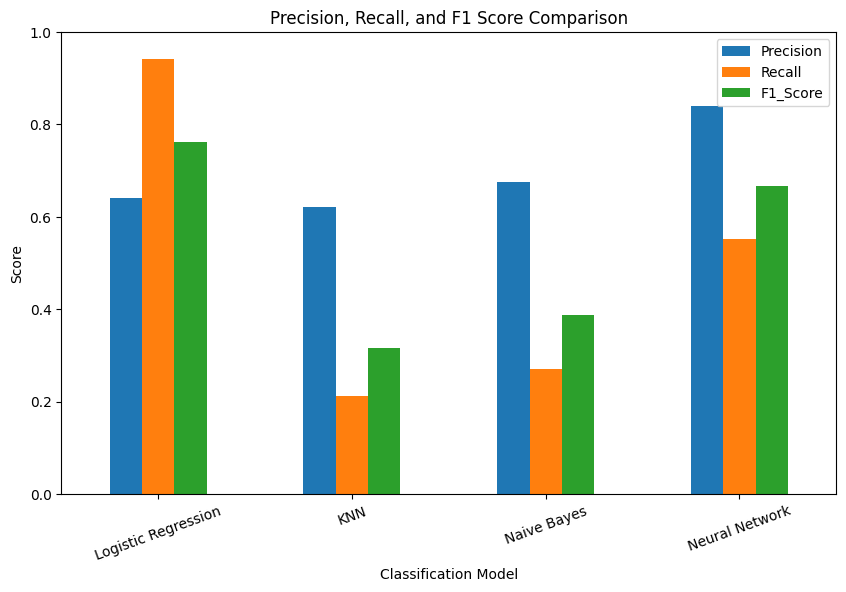

In [ ]:
comparison_df.plot(
    x="Model",
    y=["Precision" , "Recall", "F1_Score"],
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Classification Model")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 Score Comparison")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.legend()
plt.show()

**Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_knn = confusion_matrix(y_test, y_pred_knn)
cm_nb = confusion_matrix(y_test, y_pred_nb)
cm_nn = confusion_matrix(y_test, y_pred_nn)

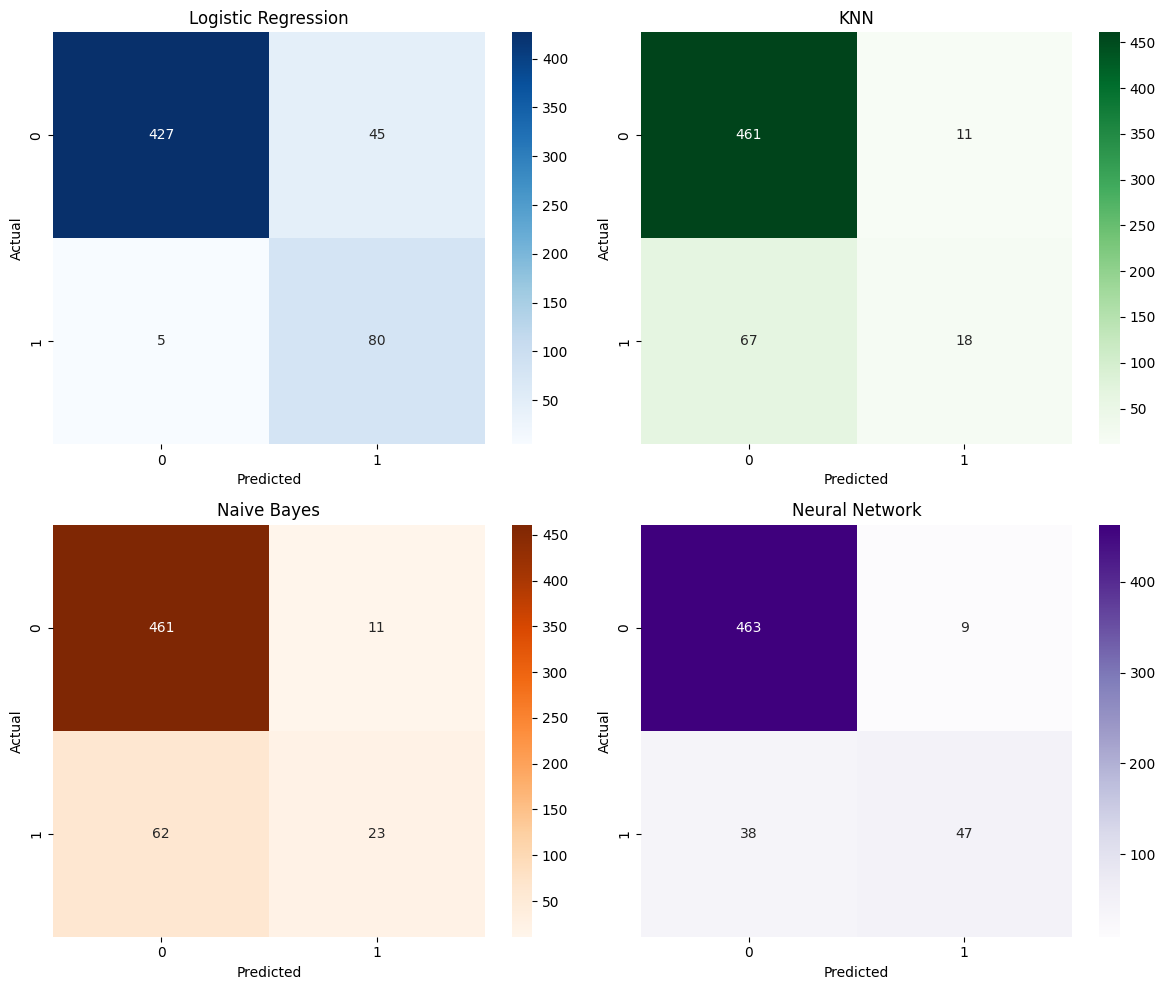

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

confusion_matrices = [
    (cm_lr, "Logistic Regression"),
    (cm_knn, "KNN"),
    (cm_nb, "Naive Bayes"),
    (cm_nn, "Neural Network")
]

cmaps = ["Blues", "Greens", "Oranges", "Purples"]

for ax, (cm, title), cmap in zip(axes.flat, confusion_matrices, cmaps):

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap=cmap,
        ax=ax
    )

    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

**AUC Score**

In [ ]:
y_prob_lr = logistic_regression.predict_proba(X_test)[:, 1]
y_prob_knn = knn.predict_proba(X_test)[:, 1]
y_prob_nb = naive_bayes.predict_proba(X_test)[:, 1]
y_prob_nn = neural_network.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import roc_auc_score

auc_lr = roc_auc_score(y_test, y_prob_lr)
auc_knn = roc_auc_score(y_test, y_prob_knn)
auc_nb = roc_auc_score(y_test, y_prob_nb)
auc_nn = roc_auc_score(y_test, y_prob_nn)

auc_scores = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN",
        "Naive Bayes",
        "Neural Network"
    ],
    "AUC": [
        auc_lr,
        auc_knn,
        auc_nb,
        auc_nn
    ]
})

auc_scores

,Model,AUC
0,Logistic Regression,0.941974
1,KNN,0.807665
2,Naive Bayes,0.873554
3,Neural Network,0.925523


**ROC Curve**

In [ ]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_prob_nb)
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)

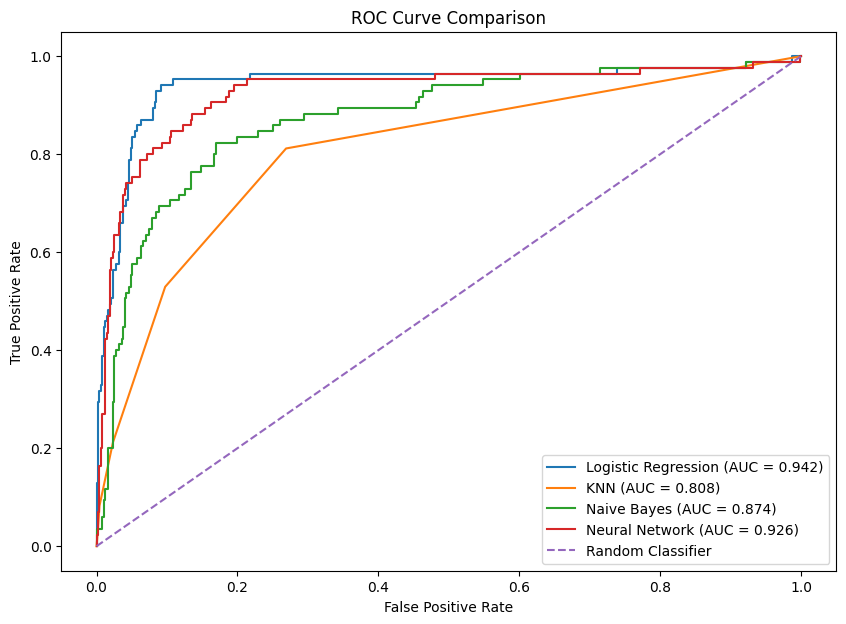

In [ ]:
plt.figure(figsize=(10, 7))

plt.plot(
    fpr_lr, tpr_lr,
    label=f"Logistic Regression (AUC = {auc_lr:.3f})"
)

plt.plot(
    fpr_knn, tpr_knn,
    label=f"KNN (AUC = {auc_knn:.3f})"
)

plt.plot(
    fpr_nb, tpr_nb,
    label=f"Naive Bayes (AUC = {auc_nb:.3f})"
)

plt.plot(
    fpr_nn, tpr_nn,
    label=f"Neural Network (AUC = {auc_nn:.3f})"
)

# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()